<a href="https://colab.research.google.com/github/DiaElix/LearnDeepLearning/blob/main/RNN_imdb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [ ]:
# Only keep top 10,000 most frequent words
vocab_size = 10000

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.imdb.load_data(num_words=vocab_size)

print("Training samples:", len(x_train))
print("Testing samples:", len(x_test))

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training samples: 25000
Testing samples: 25000


In [ ]:
max_length = 200

x_train = pad_sequences(x_train, maxlen=max_length)
x_test = pad_sequences(x_test, maxlen=max_length)

print("New training shape:", x_train.shape)

New training shape: (25000, 200)


In [ ]:
model_rnn = Sequential([

    Embedding(vocab_size, 128, input_length=max_length),

    SimpleRNN(64),

    Dense(1, activation='sigmoid')
])

model_rnn.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_rnn = model_rnn.fit(
    x_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


313/313 ━━━━━━━━━━━━━━━━━━━━ 33s 97ms/step - accuracy: 0.6855 - loss: 0.5668 - val_accuracy: 0.7570 - val_loss: 0.5038
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 41s 96ms/step - accuracy: 0.8404 - loss: 0.3675 - val_accuracy: 0.7412 - val_loss: 0.5425
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 41s 95ms/step - accuracy: 0.9324 - loss: 0.1831 - val_accuracy: 0.7968 - val_loss: 0.5144
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 29s 93ms/step - accuracy: 0.9806 - loss: 0.0637 - val_accuracy: 0.8066 - val_loss: 0.6172
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 29s 94ms/step - accuracy: 0.9952 - loss: 0.0196 - val_accuracy: 0.7994 - val_loss: 0.7317


In [ ]:
model_lstm = Sequential([

    Embedding(vocab_size, 128, input_length=max_length),

    LSTM(64),

    Dense(1, activation='sigmoid')
])

model_lstm.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_lstm = model_lstm.fit(
    x_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 88s 274ms/step - accuracy: 0.7860 - loss: 0.4464 - val_accuracy: 0.7836 - val_loss: 0.4595
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 86s 273ms/step - accuracy: 0.8917 - loss: 0.2714 - val_accuracy: 0.7396 - val_loss: 0.5921
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 89s 286ms/step - accuracy: 0.9007 - loss: 0.2450 - val_accuracy: 0.8592 - val_loss: 0.3415
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 84s 269ms/step - accuracy: 0.9507 - loss: 0.1402 - val_accuracy: 0.8474 - val_loss: 0.3741
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 88s 280ms/step - accuracy: 0.9636 - loss: 0.1059 - val_accuracy: 0.8388 - val_loss: 0.4307


In [ ]:
model_gru = Sequential([

    Embedding(vocab_size, 128, input_length=max_length),

    GRU(64),

    Dense(1, activation='sigmoid')
])

model_gru.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_gru = model_gru.fit(
    x_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 99s 304ms/step - accuracy: 0.7743 - loss: 0.4589 - val_accuracy: 0.8578 - val_loss: 0.3435
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 93s 298ms/step - accuracy: 0.9003 - loss: 0.2534 - val_accuracy: 0.8700 - val_loss: 0.3483
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 93s 297ms/step - accuracy: 0.9352 - loss: 0.1725 - val_accuracy: 0.8744 - val_loss: 0.3186
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 92s 294ms/step - accuracy: 0.9589 - loss: 0.1168 - val_accuracy: 0.8702 - val_loss: 0.3697
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 93s 296ms/step - accuracy: 0.9772 - loss: 0.0722 - val_accuracy: 0.8616 - val_loss: 0.4276


In [ ]:
rnn_acc = model_rnn.evaluate(x_test, y_test)[1]
lstm_acc = model_lstm.evaluate(x_test, y_test)[1]
gru_acc = model_gru.evaluate(x_test, y_test)[1]

print("Simple RNN Accuracy:", rnn_acc)
print("LSTM Accuracy:", lstm_acc)
print("GRU Accuracy:", gru_acc)

782/782 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - accuracy: 0.7776 - loss: 0.7067
782/782 ━━━━━━━━━━━━━━━━━━━━ 29s 36ms/step - accuracy: 0.8428 - loss: 0.4341
782/782 ━━━━━━━━━━━━━━━━━━━━ 26s 34ms/step - accuracy: 0.8611 - loss: 0.4488
Simple RNN Accuracy: 0.7775599956512451
LSTM Accuracy: 0.8428400158882141
GRU Accuracy: 0.8610799908638


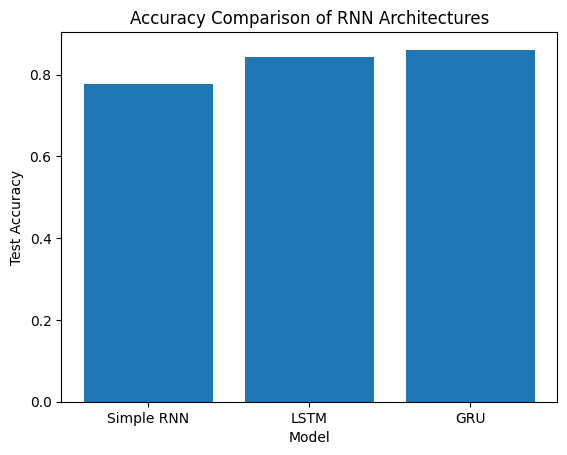

In [ ]:
models = ['Simple RNN','LSTM','GRU']
accuracy = [rnn_acc, lstm_acc, gru_acc]

plt.figure()

plt.bar(models, accuracy)

plt.title("Accuracy Comparison of RNN Architectures")
plt.ylabel("Test Accuracy")
plt.xlabel("Model")

plt.show()

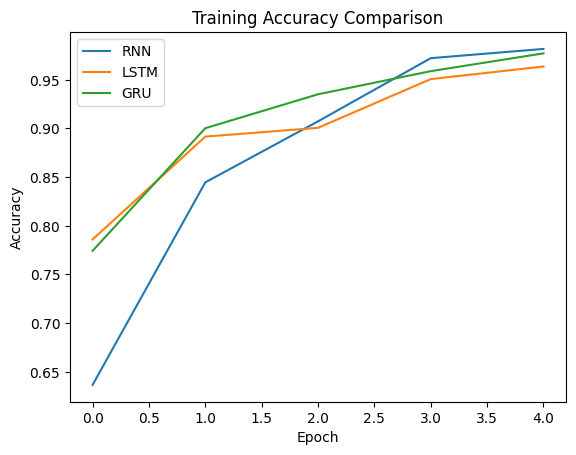

In [ ]:
plt.figure()

plt.plot(history_rnn.history['accuracy'], label='RNN')
plt.plot(history_lstm.history['accuracy'], label='LSTM')
plt.plot(history_gru.history['accuracy'], label='GRU')

plt.title("Training Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()

plt.show()

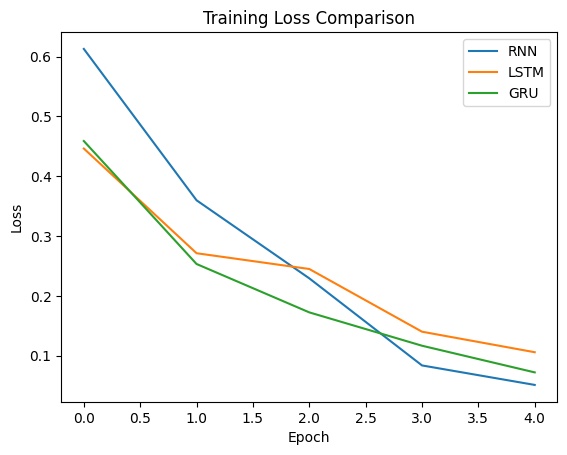

In [ ]:
plt.figure()

plt.plot(history_rnn.history['loss'], label='RNN')
plt.plot(history_lstm.history['loss'], label='LSTM')
plt.plot(history_gru.history['loss'], label='GRU')

plt.title("Training Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()

plt.show()